**General Description**

The following notebook contains the code to create, train, validate, and test a rainfall-runoff model using an LSTM network architecture. The notebook support running experiments in different large-sample hydrology datasets including: CAMELS-GB, CAMELS-US, CAMELS-DE. The details for each dataset can be read from a .yml file.

***Authors:***
- Eduardo Acuña Espinoza (eduardo.espinoza@kit.edu)
- Manuel Alvarez Chaves (manuel.alvarez-chaves@uwaterloo.c)

In [1]:
!pip install xarray

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import torch
print(torch.backends.cudnn.version())
print(torch.cuda.is_available())

90701
True


In [5]:
import dask
dask.config.set({"distributed.comm.timeouts.connect": "60s"})
dask.config.set({"distributed.deploy.lost-worker-timeout": "60s"})

In [6]:
import datetime
import random
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray as xr

from hy2dl.datasetzoo import get_dataset
from hy2dl.evaluation import calculate_metrics, get_tester
from hy2dl.modelzoo import get_model
from hy2dl.training.basetrainer import BaseTrainer
from hy2dl.utils.config import Config

base_dir = Path.cwd().resolve()
color_palette = {"observed": "#377eb8", "simulated": "#4daf4a"}

In [7]:
#import torch
#print(torch.backends.cudnn.version())
#print(torch.cuda.is_available())

Part 1. Initialize information

In [8]:
# Path to .yml file where the experiment settings are stored.
path_experiment_settings = "../examples/configs/camels_de_1h.yml"

# Read experiment settings
config = Config(path_experiment_settings, base_dir=base_dir)
config.init_experiment()
config.dump()

Dataset = get_dataset(config)
Tester = get_tester(config)

In [9]:
#import os
#print(os.environ.get("LD_LIBRARY_PATH", ""))

In [10]:
#import torch
#print(torch.backends.cudnn.version())
#print(torch.cuda.is_available())

Part 2. Create datasets and dataloaders used to train/validate the model

In [11]:
# Create training dataset
training_dataset = Dataset(cfg=config, time_period="training")
training_dataset.setup_dataset()
# Initialize training object
trainer = BaseTrainer(cfg=config, training_dataset=training_dataset)

2026-08-19 02:05:03 - Creating training dataset in memory...


Processing gauges: 100%|##########| 221/221 [00:21<00:00, 10.31entity/s]


2026-08-19 02:05:36 - Dataset created successfully.
2026-08-19 02:05:37 - Validating samples...


Validating samples: 100%|##########| 6410/6410 [00:02<00:00, 3014.22tasks/s]


2026-08-19 02:05:39 - Number of gauges with valid samples: 221
2026-08-19 02:06:22 - Number of valid samples: 29 742 540
2026-08-19 02:06:22 - Mapping ids, dates and features to their corresponding indexes
2026-08-19 02:06:45 - Dataset was successfully standardized.
2026-08-19 02:06:45 - Static attributes were successfully standardized.
2026-08-19 02:06:46 - Time required to process the dataset: 0:01:43
2026-08-19 02:07:01 - ----------------Details training dataloader-----------------
2026-08-19 02:07:01 - Batch structure (number of batches: 116181)
2026-08-19 02:07:01 -              Key              |            Shape             
2026-08-19 02:07:03 - x_d_1h
2026-08-19 02:07:03 -       discharge_spec_obs      |    torch.Size([256, 96])     
2026-08-19 02:07:03 -      air_temperature_mean     |    torch.Size([256, 96])     
2026-08-19 02:07:03 -     global_radiation_mean     |    torch.Size([256, 96])     
2026-08-19 02:07:03 -   air_pressure_surface_mean   |    torch.Size([256, 96]) 

In [12]:
import torch
print(torch.backends.cudnn.version())
print(torch.cuda.is_available())

90701
True


In [13]:
validation_dataset = Dataset(cfg=config, time_period="validation")
validation_dataset.setup_dataset(check_nan=False, path_scaler = config.path_save_folder / "scaler.yml" )
tester_validation = Tester(cfg=config, evaluation_dataset=validation_dataset)

2026-08-19 02:07:03 - Creating validation dataset in memory...


Processing gauges: 100%|##########| 221/221 [00:19<00:00, 11.52entity/s]


2026-08-19 02:07:25 - Dataset created successfully.
2026-08-19 02:07:25 - Validating samples...


Validating samples: 100%|##########| 1769/1769 [00:00<00:00, 11256.31tasks/s]


2026-08-19 02:07:25 - Number of gauges with valid samples: 221
2026-08-19 02:07:33 - Number of valid samples: 5 807 659
2026-08-19 02:07:33 - Mapping ids, dates and features to their corresponding indexes
2026-08-19 02:07:37 - Dataset was successfully standardized.
2026-08-19 02:07:37 - Static attributes were successfully standardized.
2026-08-19 02:07:38 - Time required to process the dataset: 0:00:34


Part 3. Train model

In [14]:
# Training report structure
validation_headers = "".join([f"{m:^10}|" for m in config.validation_metric])
config.logger.info("Training model".center(60, "-"))
config.logger.info(f"{'':^16}|{'Training':^21}|{'Validation':^{(11 * len(config.validation_metric)) + 10}}|")
config.logger.info(f"{'Epoch':^5}|{'LR':^10}|{'Loss':^10}|{'Time':^10}|{validation_headers}{'Time':^10}|")

# Loop through epochs
total_time = time.time()
for epoch in range(1, config.epochs + 1):
    trainer.train_model(epoch=epoch)  # Training
    tester_validation.validate_model(model=trainer.model, epoch=epoch)  # Validation
    config.logger.info(trainer.report + tester_validation.validation_report)  # report

config.logger.info(f"Total training time: {datetime.timedelta(seconds=int(time.time() - total_time))}\n")
shutil.rmtree(tester_validation.path_zarr, ignore_errors=True)  # delete validation results

2026-08-19 02:09:18 - -----------------------Training model-----------------------
2026-08-19 02:09:18 -                 |      Training       |     Validation      |
2026-08-19 02:09:18 - Epoch|    LR    |   Loss   |   Time   |   nse    |   Time   |


2026-08-19 02:21:22 -   1  | 0.00050  |  1.949   | 0:12:03  |          |          |


2026-08-19 02:33:21 -   2  | 0.00050  |  1.716   | 0:11:58  |          |          |


2026-08-19 02:45:07 -   3  | 0.00050  |  1.623   | 0:11:46  |          |          |


2026-08-19 02:56:50 -   4  | 0.00050  |  1.566   | 0:11:42  |          |          |


...

2026-08-19 03:32:43 -   7  | 0.00010  |  1.404   | 0:11:42  |          |          |


2026-08-19 03:44:25 -   8  | 0.00005  |  1.380   | 0:11:41  |          |          |


2026-08-19 03:56:06 -   9  | 0.00005  |  1.373   | 0:11:40  |          |          |


/opt/bwhpc/common/jupyter/ai/2026-03-06/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


2026-08-19 04:08:32 -  10  | 0.00005  |  1.364   | 0:11:43  |  0.281   | 0:00:43  |
2026-08-19 04:08:32 - Total training time: 1:59:14



Part 4. Test model

In [15]:
# If I already trained a model, I can re-construct it using the saved parameters from a given epoch
#model = get_model(config).to(config.device)
#model.load_state_dict(torch.load(config.path_save_folder / "model" / f"model_epoch_{config.epochs}", map_location=config.device))

In [16]:
testing_dataset = Dataset(cfg=config, time_period="testing")
testing_dataset.setup_dataset(check_nan=False, path_scaler = config.path_save_folder / "scaler.yml" )
tester_testing = Tester(cfg=config, evaluation_dataset=testing_dataset)

config.logger.info("Testing model...")
testing_time = time.time()
tester_testing.evaluate_model(model = trainer.model)
config.logger.info("Testing completed.")
config.logger.info(f"Total testing time: {datetime.timedelta(seconds=int(time.time() - testing_time))}\n")

2026-08-19 04:12:11 - Creating testing dataset in memory...


Processing gauges: 100%|##########| 221/221 [01:03<00:00,  3.50entity/s]


2026-08-19 04:13:23 - Dataset created successfully.
2026-08-19 04:13:23 - Validating samples...


Validating samples: 100%|##########| 1769/1769 [00:00<00:00, 11196.30tasks/s]


2026-08-19 04:13:23 - Number of gauges with valid samples: 221
2026-08-19 04:13:37 - Number of valid samples: 9 690 187
2026-08-19 04:13:37 - Mapping ids, dates and features to their corresponding indexes
2026-08-19 04:13:44 - Dataset was successfully standardized.
2026-08-19 04:13:44 - Static attributes were successfully standardized.
2026-08-19 04:13:45 - Time required to process the dataset: 0:01:33
2026-08-19 04:13:49 - Testing model...


2026-08-19 04:14:53 - Testing completed.
2026-08-19 04:14:53 - Total testing time: 0:01:04



Part 5. Initial analysis

In [17]:
test_results = xr.open_zarr(tester_testing.path_zarr)
testing_metrics = calculate_metrics(ds_results=test_results, metric_name = config.testing_metrics)
testing_metrics.to_zarr(config.path_save_folder / "testing_metrics.zarr", mode="w")

/opt/bwhpc/common/jupyter/ai/2026-03-06/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


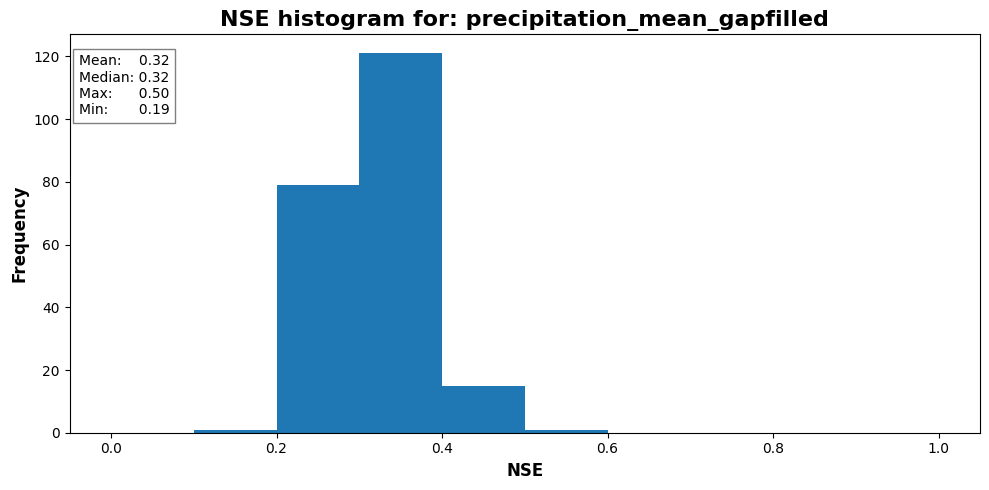

In [18]:
# Loss testing
target_of_interest = random.sample(list(testing_metrics.feature.values), 1)[0]
test_metric = testing_metrics.sel(feature=target_of_interest, metric="nse").round(3).T.to_pandas().dropna()
# Plot the histogram
plt.figure(figsize=(10, 5))
plt.hist(test_metric, bins = np.linspace(0.0, 1.0, 11).tolist())
# Add NSE statistics to the plot
plt.text(
    0.01,
    0.8,
    (
        f"Mean: {'%.2f' % test_metric.mean():>7}\n"
        f"Median: {'%.2f' % test_metric.median():>0}\n"
        f"Max: {'%.2f' % test_metric.max():>9}\n"
        f"Min: {'%.2f' % test_metric.min():>10}"
    ),
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white", alpha=0.5),
)

# Format plot
plt.xlabel("NSE", fontsize=12, fontweight="bold")
plt.ylabel("Frequency", fontsize=12, fontweight="bold")
plt.title(f"NSE histogram for: {target_of_interest}", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

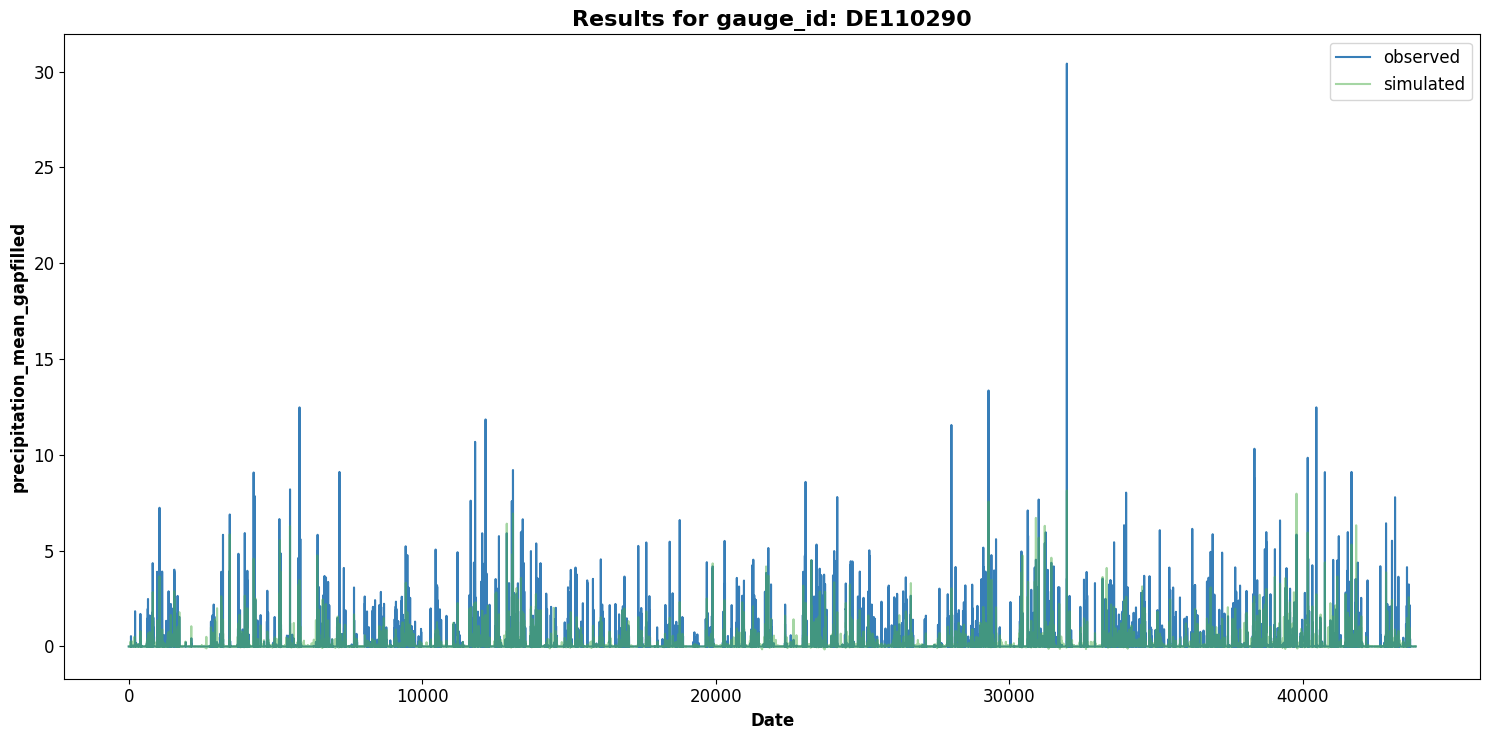

In [19]:
# Plot simulated and observed discharges
basin_to_analyze = random.sample(list(test_results.gauge_id.values), 1)[0]
y_sim = test_results.sel(gauge_id=basin_to_analyze, feature=target_of_interest)["y_sim"].compute().values
y_obs = test_results.sel(gauge_id=basin_to_analyze, feature=target_of_interest)["y_obs"].compute().values

plt.figure(figsize=(15, 7.5))
plt.plot(y_obs, label="observed", color=color_palette["observed"])
plt.plot(y_sim, label="simulated", alpha=0.5, color=color_palette["simulated"])

# Format plot
plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel(target_of_interest, fontsize=12, fontweight="bold")
plt.title(f"Results for gauge_id: {basin_to_analyze}", fontsize=16, fontweight="bold")
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend(loc="upper right", fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import pandas as pd

def calculate_nse(obs, sim):
    """Compute Nash-Sutcliffe Efficiency, ignoring NaNs."""
    obs = np.asarray(obs)
    sim = np.asarray(sim)
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs, sim = obs[mask], sim[mask]
    if len(obs) == 0:
        return np.nan
    numerator = np.sum((obs - sim) ** 2)
    denominator = np.sum((obs - np.mean(obs)) ** 2)
    if denominator == 0:
        return np.nan
    return 1 - (numerator / denominator)

# Loop over all catchments and compute NSE
nse_results = []
for gauge_id in test_results.gauge_id.values:
    y_sim = test_results.sel(gauge_id=gauge_id, feature=target_of_interest)["y_sim"].compute().values
    y_obs = test_results.sel(gauge_id=gauge_id, feature=target_of_interest)["y_obs"].compute().values
    nse = calculate_nse(y_obs, y_sim)
    nse_results.append({"gauge_id": gauge_id, "NSE": nse})

# Build table
nse_df = pd.DataFrame(nse_results).sort_values("NSE", ascending=False).reset_index(drop=True)

# Quick summary stats
print(nse_df.describe())
nse_df

              NSE
count  217.000000
mean     0.320106
std      0.057912
min      0.187841
25%      0.274922
50%      0.320071
75%      0.357773
max      0.501064


,gauge_id,NSE
0,DE111260,0.501064
1,DE111860,0.488461
2,DE111870,0.486000
3,DE111120,0.482729
4,DE111440,0.470051
...,...,...
216,DE111200,0.187841
217,DE110220,NaN
218,DE110230,NaN
219,DE111250,NaN


In [21]:
nse_df.head(20)

,gauge_id,NSE
0,DE111260,0.501064
1,DE111860,0.488461
2,DE111870,0.486000
3,DE111120,0.482729
4,DE111440,0.470051
5,DE111490,0.446914
6,DE110940,0.445532
7,DE110340,0.428421
8,DE111140,0.425512
9,DE110990,0.411332


In [22]:
# Simple export
nse_df.to_excel("NSE_per_gauge_id_results.xlsx", index=False, sheet_name="NSE Results")